# Наивный Байес и kNN

## Пример решения задачи классификации с синтетическими данными

In [11]:
#import numpy as np
#import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from mlxtend.plotting import plot_decision_regions

In [ ]:
# Создаем искусственный датасет для классификации
X, y = make_blobs(n_samples=600, n_features=2,
                           centers=[[2, -2],[-2, 2], [1, 2], [-1, -2]],
                           cluster_std=[0.5, 1, 0.5, 0.7], random_state=10)

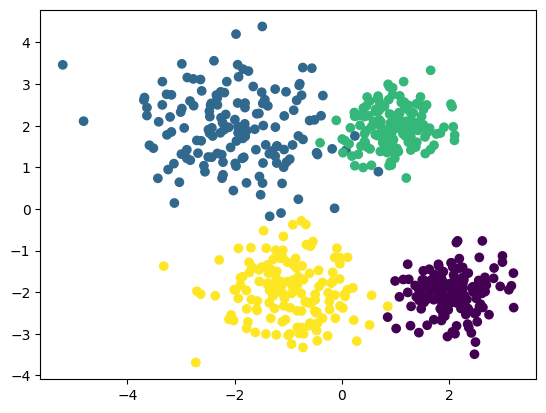

In [ ]:
plt.scatter(X[:,0],X[:,1], c=y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, stratify = y)
X

array([[ 1.13635891,  2.06312774],
       [-1.48005769,  0.62212417],
       [-2.76360434,  2.48078874],
       ...,
       [ 2.10863257, -2.99719688],
       [-1.85733071,  1.21596444],
       [ 2.31012725, -2.53428385]])

In [ ]:
#clf = GaussianNB()
clf = KNeighborsClassifier(n_neighbors=3)

clf.fit(X_train, y_train)
clf_pred = clf.predict(X_train)

clf_accuracy = accuracy_score(y_train, clf_pred)
clf_accuracy

0.9822222222222222

In [ ]:
clf_pred = clf.predict(X_test)

clf_accuracy = accuracy_score(y_test, clf_pred)
clf_accuracy

0.9733333333333334

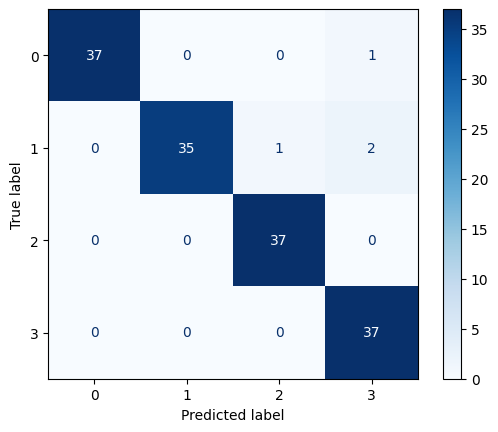

In [ ]:
cm = confusion_matrix(y_test, clf_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)

/usr/local/lib/python3.11/dist-packages/mlxtend/plotting/decision_regions.py:346: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


<Axes: >

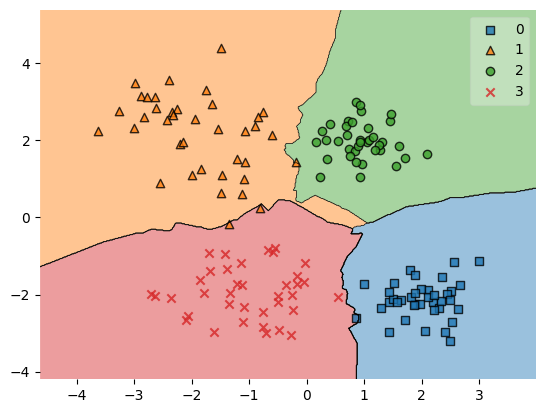

In [ ]:
#feature_indexes = [2, 3]
title1 = 'Границы решений'
plot_decision_regions(X_test, y_test, clf)
#plot_decision_regions(X_train, y_train, clf)

In [ ]:
print(classification_report(y_test, clf_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        38
           1       1.00      0.92      0.96        38
           2       0.97      1.00      0.99        37
           3       0.93      1.00      0.96        37

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.98      0.97      0.97       150



## Задание 1. Задача классификации

Для набора данных "Ирисы Фишера":


1.   Загрузить данные, разбить на тренировочную и обучающую выборки.
2.   Обучить на тренировочной, оценить точность модели на тестовой выборке для GaussianNB(), MultinomialNB(), KNeighborsClassifier(). Прокомментировать полученные результаты. В каждом случае построить матрицы ConfusionMatrix, отчеты о классификации (4 балла).
3. Показать, что точность модели kNN зависит от выбранного числа соседей (2 балла).

При желании можно строить и границы решений. Для этого будет полезна следующая функция. Но, обратите внимание, в ней используются только 2 признака (из 4 в рассматриваемом наборе).


In [10]:
# использует только 2 признака для обучения!
# X, y - набор данных для отображения, X_train, y_train - данные для обучения
def decision_boundary_plot(X, y, X_train, y_train, clf, feature_indexes, title=None):
    feature1_name, feature2_name = X.columns[feature_indexes]
    X_feature_columns = X.values[:, feature_indexes]
    X_train_feature_columns = X_train[:, feature_indexes]
    clf.fit(X_train_feature_columns, y_train)

    plot_decision_regions(X=X_feature_columns, y=y.values, clf=clf)
    plt.xlabel(feature1_name)
    plt.ylabel(feature2_name)
    plt.title(title)

Для загрузки данных используйте код.

In [2]:
from sklearn.datasets import load_iris

In [5]:
X, y = load_iris(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=5)

In [6]:
clf = GaussianNB()
clf.fit(X_train, y_train)
clf_pred = clf.predict(X_train)

clf_accuracy = accuracy_score(y_train, clf_pred)
clf_accuracy

0.9732142857142857

In [7]:
clf_pred = clf.predict(X_test)
clf_accuracy = accuracy_score(y_test, clf_pred)
clf_accuracy

0.9210526315789473

А для построения границы решения следующий код.

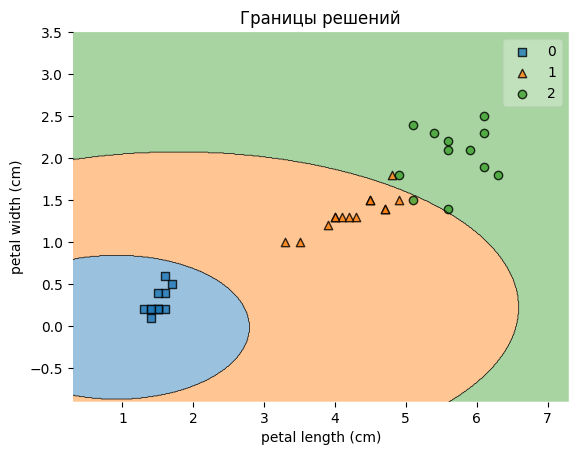

In [12]:
feature_indexes = [2, 3]
title1 = 'Границы решений'
decision_boundary_plot(X_test, y_test, X_train.values, y_train.values, clf, feature_indexes, title1)

## Задание 2. Задача регрессии

Для набора данных "diamonds" из пакета seaborn:

1. Загрузите данные. Изучите набор данных, есть хорошая зависимость между числом карат бриллианта и его тремя x, y, z размерами.

2. Создайте новый поднабор данных df1 = df[['x', 'y', 'z', 'carat']] и очистите его от выбросов на основе ящика с усами.

3. Полученный набор данных разделите на тренировочную и тестовую выборку, обучите kNN регрессор и оцените точность модели. Используйте все известные Вам метрики оценки качества решения задачи регрессии (3 балла).

Для загрузки данных будет полезен код.

In [ ]:
import seaborn as sns

In [ ]:
df = sns.load_dataset('diamonds')
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


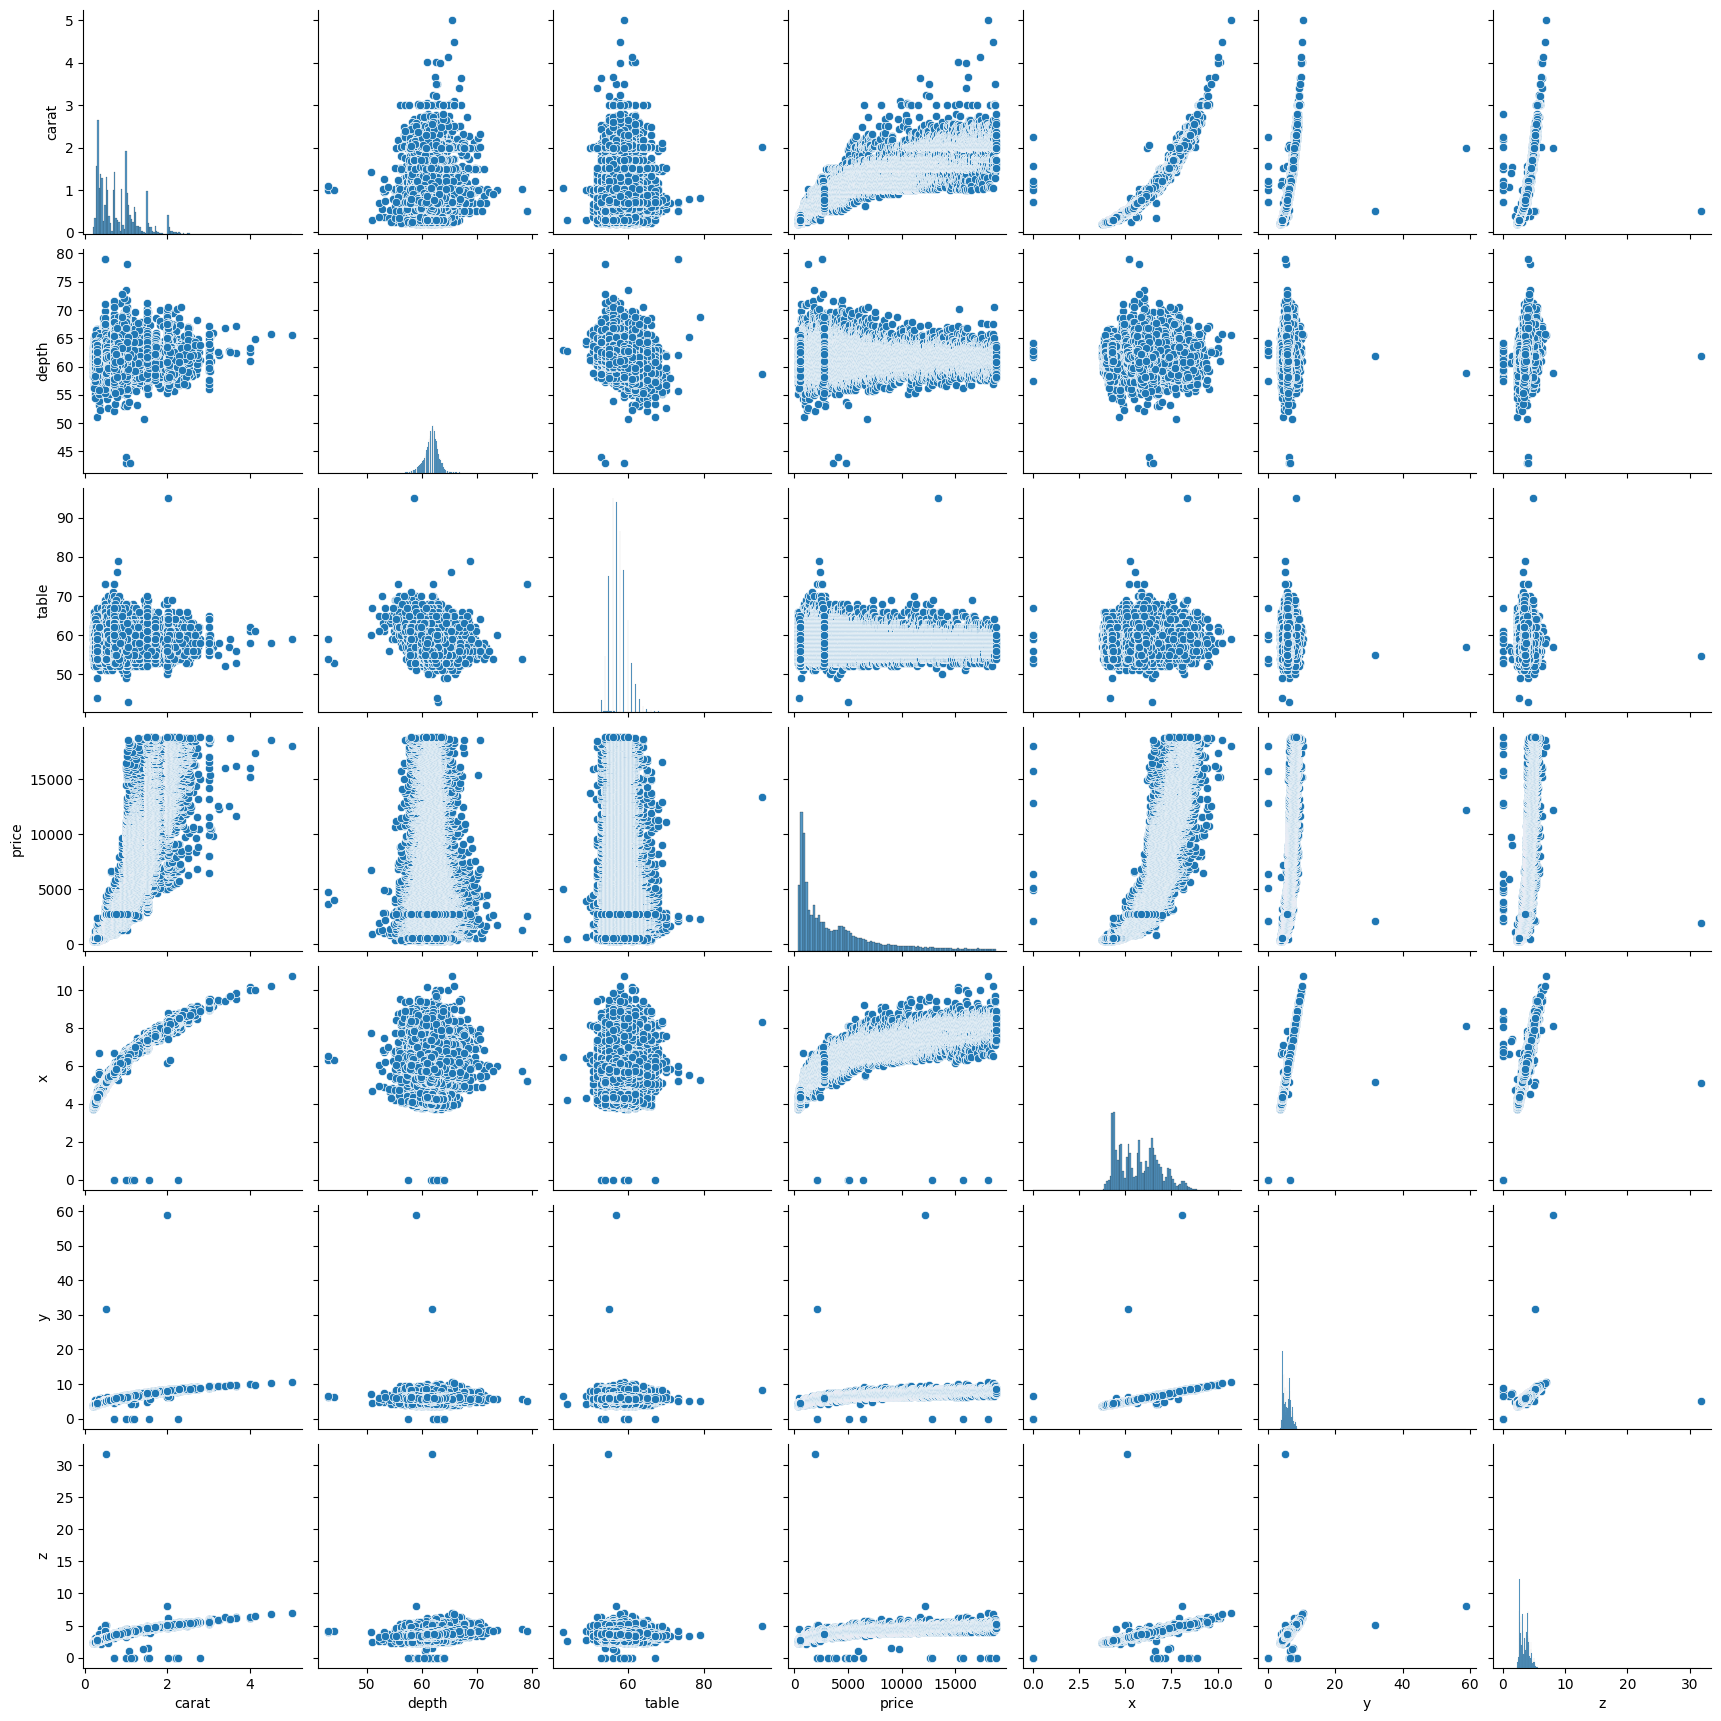

In [ ]:
sns.pairplot(df) # при желании можно посмотреть на pairplot, видна зависимость между carat и x,y,z

Видна высокая корреляция carat с x, y, z.

In [ ]:
df.corr(numeric_only=True).style.background_gradient(cmap='coolwarm')

,carat,depth,table,price,x,y,z
carat,1.000000,0.028224,0.181618,0.921591,0.975094,0.951722,0.953387
depth,0.028224,1.000000,-0.295779,-0.010647,-0.025289,-0.029341,0.094924
table,0.181618,-0.295779,1.000000,0.127134,0.195344,0.183760,0.150929
price,0.921591,-0.010647,0.127134,1.000000,0.884435,0.865421,0.861249
x,0.975094,-0.025289,0.195344,0.884435,1.000000,0.974701,0.970772
y,0.951722,-0.029341,0.183760,0.865421,0.974701,1.000000,0.952006
z,0.953387,0.094924,0.150929,0.861249,0.970772,0.952006,1.000000


Создаем новый поднабор данных.

In [ ]:
df1 = df[['x', 'y', 'z', 'carat']]
df1.shape

(53940, 4)

In [ ]:
df1.describe().T # видно наличие выбросов. ГДЕ ВИДНО?

,count,mean,std,min,25%,50%,75%,max
x,53940.0,5.731157,1.121761,0.0,4.71,5.70,6.54,10.74
y,53940.0,5.734526,1.142135,0.0,4.72,5.71,6.54,58.90
z,53940.0,3.538734,0.705699,0.0,2.91,3.53,4.04,31.80
carat,53940.0,0.797940,0.474011,0.2,0.40,0.70,1.04,5.01


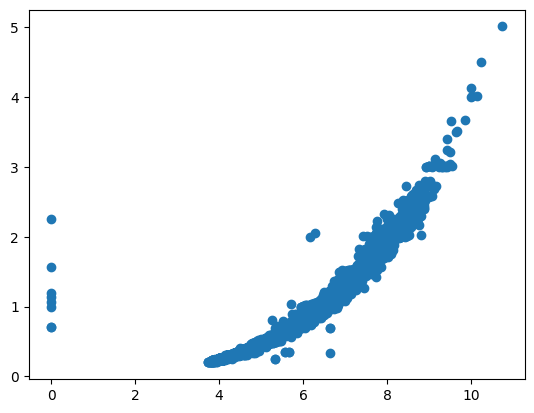

In [ ]:
plt.scatter(df1['x'], df1['carat'])  # Здесь тоже видно выбросы

Очистим df1 от выбросов следующим образом. Все, что выходит за 1.5 межквартильного интервала - считаем выбросом и удаляем.

In [ ]:
Q1 = df1.quantile(0.25)
Q3 = df1.quantile(0.75)
IQR = Q3 - Q1

outliers = (df1 < (Q1 - 1.5 * IQR)) | (df1 > (Q3 + 1.5 * IQR))

df2 = df1[~outliers.any(axis=1)]
df2.shape

(52033, 4)

In [ ]:
df2.describe().T # Видно, что стало меньше выбросов

,count,mean,std,min,25%,50%,75%,max
x,52033.0,5.639868,1.026844,3.73,4.69,5.65,6.48,8.42
y,52033.0,5.642594,1.020042,3.68,4.70,5.66,6.47,8.35
z,52033.0,3.483037,0.634845,1.41,2.89,3.49,4.01,5.37
carat,52033.0,0.748625,0.402067,0.20,0.39,0.70,1.02,2.00


Теперь мы готовы сформировать тренировочную и тестовую выборки.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(df2[['x','y','z']], df2['carat'], test_size = 0.2, random_state=12)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
knn_model = KNeighborsRegressor(n_neighbors=5).fit(X_train, y_train)

# Score
score_knn = knn_model.score(X_test, y_test)  # что это за метрика?
score_knn

0.9988354654533848

Дальше Ваш код.